<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/01_machine_learning_foundations/43_voting_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import VotingClassifier

from sklearn.metrics import accuracy_score

In [2]:
X, y = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=5,
    random_state=42
)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_acc = accuracy_score(
    y_test,
    lr.predict(X_test)
)

print("Logistic Regression:", lr_acc)

Logistic Regression: 0.82


In [5]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_acc = accuracy_score(
    y_test,
    dt.predict(X_test)
)

print("Decision Tree:", dt_acc)

Decision Tree: 0.88


In [6]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_acc = accuracy_score(
    y_test,
    knn.predict(X_test)
)

print("KNN:", knn_acc)

KNN: 0.87


In [7]:
voting = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('dt', dt),
        ('knn', knn)
    ],
    voting='hard'
)

voting.fit(
    X_train,
    y_train
)

voting_acc = accuracy_score(
    y_test,
    voting.predict(X_test)
)

print(
    "Voting Classifier:",
    voting_acc
)

Voting Classifier: 0.89


In [8]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "KNN",
        "Voting Classifier"
    ],

    "Accuracy":[
        lr_acc,
        dt_acc,
        knn_acc,
        voting_acc
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.82
1,Decision Tree,0.88
2,KNN,0.87
3,Voting Classifier,0.89


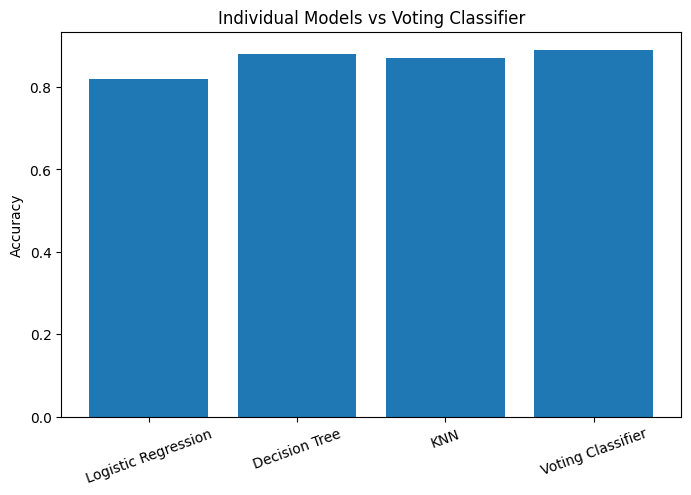

In [9]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.ylabel("Accuracy")

plt.title(
    "Individual Models vs Voting Classifier"
)

plt.xticks(rotation=20)

plt.show()

## Conclusion

Voting Classifier combines predictions from multiple machine learning models.

Observations:
- Different models contribute different strengths.
- Majority voting can improve stability.
- Ensemble methods often perform better than individual models.
- Voting is a simple but powerful ensemble technique.